# Choosing and Justifying Random Effects Structure

## Overview

Random effects structure is the most consequential and most commonly misspecified aspect of mixed models. Getting it wrong in either direction causes problems: too little structure inflates type I error; too much structure produces singular fits and unreliable estimates.

This notebook covers:
1. How to identify the correct grouping structure from your study design
2. Nested vs. crossed random effects — what the difference is and how to specify each
3. Random intercepts vs. random slopes — when each is justified
4. How to formally compare and justify random effects structure
5. How to handle singular fits and overly complex structures

## The Core Question

> **What is the source of non-independence in my data?**

Every random effect answers this question. If multiple measurements come from the same site, site is a random effect. If the same subject is measured across conditions, subject is a random effect. If the effect of a treatment plausibly varies by subject, that's a random slope.

---

## Setup

In [17]:
library(tidyverse)
library(ggplot2)
library(lme4)
library(lmerTest)
library(broom.mixed)
library(performance)

set.seed(42)

---

## Step 1: Read the Random Effects Structure from the Study Design

The random effects structure should be determined by the data collection design — not by model fit. Ask:

| Design Feature | Random Effect |
|---|---|
| Multiple observations per subject | `(1 \| subject)` |
| Multiple observations per site | `(1 \| site)` |
| Effect of treatment varies by subject | `(treatment \| subject)` |
| Plots nested within fields | `(1 \| field/plot)` or `(1 \| field) + (1 \| field:plot)` |
| Each subject sees every item (psycholinguistics, ecology surveys) | `(1 \| subject) + (1 \| item)` |
| Repeated measures across time within subjects | `(time \| subject)` |

> **Design determines structure. Data determines whether the structure is estimable.**

In [18]:
# ── Example: ecology field study design ──────────────────────────────────────
# Study: invertebrate density measured at 3 plots per site, 15 sites
# Treatment applied at site level (not plot level)
# → Plots nested within sites
# → Treatment effect is at site level
# → Correct random effect: (1 | site/plot) or (1 | site) + (1 | site:plot)

# ── Example: clinical trial ───────────────────────────────────────────────────
# Study: patients measured at baseline, 3 months, 6 months
# Drug vs. placebo applied between-subject
# → Repeated measures within patient
# → Drug effect is fixed; time trajectory varies by patient
# → Correct structure: (time | patient)

# ── Example: crossed design (ecology survey) ──────────────────────────────────
# Study: 20 observers survey 30 sites; each observer visits each site once
# → Both observers and sites are random effects
# → They are crossed: every observer × site combination
# → Correct structure: (1 | observer) + (1 | site)

# ── Diagram: check whether effects are nested or crossed ─────────────────────
# NESTED: plot IDs only make sense within their site
#   Site A: plots 1, 2, 3  |  Site B: plots 1, 2, 3  (same numbers, different plots)
#   → (1 | site / plot)

# CROSSED: subjects and items exist independently of one another
#   Subject 1 sees item A, B, C  |  Subject 2 sees item A, B, C
#   → (1 | subject) + (1 | item)

cat("Study design determines random effects. Fit accordingly.\n")

Study design determines random effects. Fit accordingly.


---

## Nested Random Effects

Groups at a lower level exist only within a specific group at the higher level. Plots within sites, students within schools, samples within cores.

**Critical warning:** If plot IDs are not unique across sites (plot 1 exists at site A and site B), you must use the nesting operator `/` or manually create unique IDs. This is the single most common random effects coding error.

In [19]:
# ── Simulate: multiple observations per plot ──────────────────────────────────
n_sites <- 12; n_plots <- 4; n_obs <- 3  # <-- add observations per plot
N <- n_sites * n_plots * n_obs

site_re <- rnorm(n_sites, 0, 3)
plot_re  <- rnorm(n_sites * n_plots, 0, 1.5)  # one RE per unique plot

nested_data <- tibble(
  site      = rep(paste0("site", 1:n_sites), each = n_plots * n_obs),
  plot      = rep(paste0("plot", 1:n_plots), times = n_sites, each = n_obs),  # NON-unique
  plot_uid  = paste(site, plot, sep = "_"),
  treatment = rep(c("control", "treated"), each = n_plots * n_obs * (n_sites / 2)),
  predictor = rnorm(N, 5, 2),
  response  = 20 + 3 * (treatment == "treated") +
               0.8 * predictor +
               rep(rep(site_re, each = n_plots), each = n_obs) +
               rep(plot_re, each = n_obs) +
               rnorm(N, 0, 1)
)

# ── Demonstrate the ID problem ────────────────────────────────────────────────
cat("Non-unique plot IDs (WRONG — lme4 treats plot1 as same across sites):\n")
head(nested_data %>% select(site, plot, plot_uid), 8)

# ── WRONG: non-unique plot IDs treated as crossed ────────────────────────────
model_wrong <- lmer(response ~ treatment + predictor +
                      (1 | site) + (1 | plot),   # plot is NOT unique!
                    data = nested_data, REML = TRUE)

# ── CORRECT option 1: nesting operator ───────────────────────────────────────
model_nested1 <- lmer(response ~ treatment + predictor +
                        (1 | site / plot),        # expands to (1|site) + (1|site:plot)
                      data = nested_data, REML = TRUE)

# ── CORRECT option 2: unique plot IDs ────────────────────────────────────────
model_nested2 <- lmer(response ~ treatment + predictor +
                        (1 | site) + (1 | plot_uid),
                      data = nested_data, REML = TRUE)

# Both correct options give identical results
cat("\nVariance components (correct nested model):\n")
broom.mixed::tidy(model_nested2, effects = "ran_pars") %>%
  mutate(across(where(is.numeric), ~ round(.x, 3))) %>% print()

Non-unique plot IDs (WRONG — lme4 treats plot1 as same across sites):


site,plot,plot_uid
<chr>,<chr>,<chr>
site1,plot1,site1_plot1
site1,plot1,site1_plot1
site1,plot1,site1_plot1
site1,plot2,site1_plot2
site1,plot2,site1_plot2
site1,plot2,site1_plot2
site1,plot3,site1_plot3
site1,plot3,site1_plot3



Variance components (correct nested model):
# A tibble: 3 × 4
  effect   group    term            estimate
  <chr>    <chr>    <chr>              <dbl>
1 ran_pars plot_uid sd__(Intercept)    1.86 
2 ran_pars site     sd__(Intercept)    2.50 
3 ran_pars Residual sd__Observation    0.983


---

## Crossed Random Effects

Groups at two levels exist independently and every combination is possible. The most common example in ecology: subjects (or sites) × items (or survey occasions), where every subject can in principle encounter every item.

In [20]:
# ── Simulate: observers × sites (crossed) ────────────────────────────────────
n_obs <- 15; n_sites_c <- 20
obs_re  <- rnorm(n_obs,     0, 2)   # observer bias
site_re <- rnorm(n_sites_c, 0, 4)   # site quality

crossed_data <- expand_grid(
  observer = paste0("obs",  1:n_obs),
  site     = paste0("site", 1:n_sites_c)
) %>%
  mutate(
    vegetation = rnorm(n(), 5, 2),
    count = rpois(
      n(),
      lambda = exp(
        1.5 + 0.2 * vegetation +
        rep(obs_re,  times = n_sites_c) +
        rep(site_re, each  = n_obs)
      )
    )
  )

cat(sprintf("Crossed design: %d observers × %d sites = %d observations\n",
            n_obs, n_sites_c, nrow(crossed_data)))

# ── Fit crossed random effects model ─────────────────────────────────────────
model_crossed <- lme4::glmer(
  count ~ vegetation + (1 | observer) + (1 | site),
  data   = crossed_data,
  family = poisson
)
summary(model_crossed)

# ── Variance decomposition ────────────────────────────────────────────────────
broom.mixed::tidy(model_crossed, effects = "ran_pars") %>%
  mutate(pct_variance = estimate^2 / sum(estimate^2) * 100) %>%
  mutate(across(where(is.numeric), ~ round(.x, 2)))
# How much variance is attributable to observers vs. sites vs. residual?

Crossed design: 15 observers × 20 sites = 300 observations


Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
"Model is nearly unidentifiable: very large eigenvalue
 - Rescale variables?;Model is nearly unidentifiable: large eigenvalue ratio
 - Rescale variables?"


Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: poisson  ( log )
Formula: count ~ vegetation + (1 | observer) + (1 | site)
   Data: crossed_data

      AIC       BIC    logLik -2*log(L)  df.resid 
 15648216  15648231  -7824104  15648208       296 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-781.58  -20.10   -1.28    5.62 1650.02 

Random effects:
 Groups   Name        Variance Std.Dev.
 site     (Intercept)  2.593   1.610   
 observer (Intercept) 15.338   3.916   
Number of obs: 300, groups:  site, 20; observer, 15

Fixed effects:
              Estimate Std. Error  z value Pr(>|z|)    
(Intercept)  5.9229062  0.6493957    9.121   <2e-16 ***
vegetation  -0.1532051  0.0002363 -648.433   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Correlation of Fixed Effects:
           (Intr)
vegetation -0.001
optimizer (Nelder_Mead) convergence code: 0 (OK)
Model is nearly unidentifiable: very la

effect,group,term,estimate,pct_variance
<chr>,<chr>,<chr>,<dbl>,<dbl>
ran_pars,site,sd__(Intercept),1.61,14.46
ran_pars,observer,sd__(Intercept),3.92,85.54


---

## Random Intercepts vs. Random Slopes

Random intercepts allow groups to differ in their baseline. Random slopes additionally allow the effect of a predictor to differ across groups. Whether to include random slopes depends on the study design and whether group-level variation in slopes is theoretically plausible.

,npar,AIC,BIC,logLik,-2*log(L),Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
m_ri,4,1194.472,1207.666,-593.2362,1186.472,NA,NA,NA
m_rs,6,1192.098,1211.888,-590.0492,1180.098,6.374135,2,0.04129279



Variance components — random slopes model:
# A tibble: 4 × 4
  effect   group    term                       estimate
  <chr>    <chr>    <chr>                         <dbl>
1 ran_pars subject  sd__(Intercept)                6.81
2 ran_pars subject  sd__treatment                  1.92
3 ran_pars subject  cor__(Intercept).treatment    -0.81
4 ran_pars Residual sd__Observation                3.95


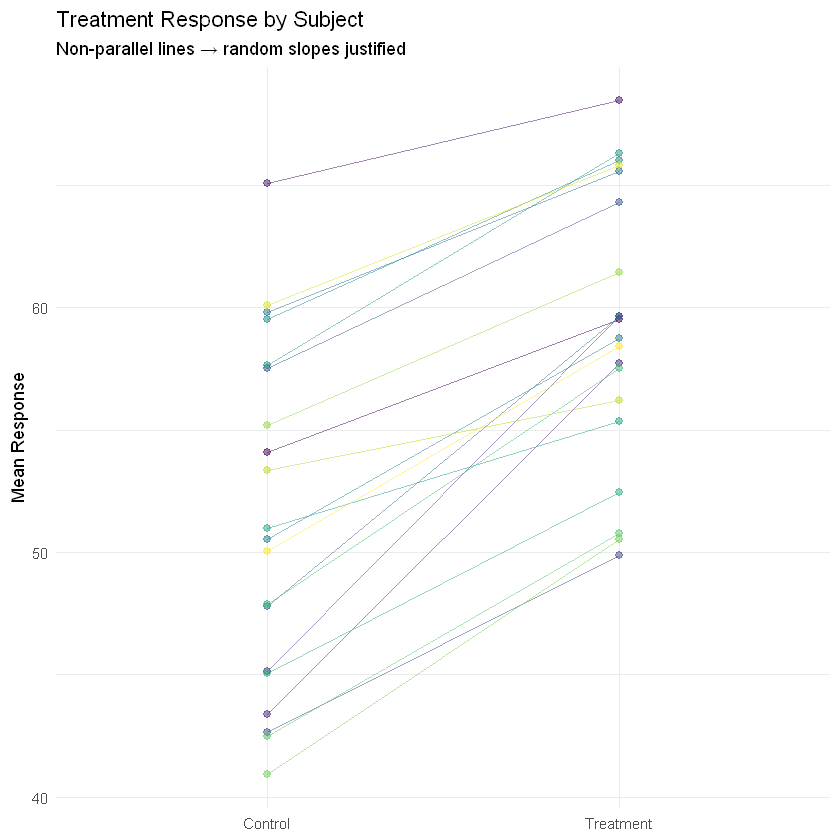

In [21]:
# ── When do random slopes make sense? ────────────────────────────────────────
# YES: The predictor varies within groups AND its effect could plausibly differ
#   - Time measured within subjects: subjects may deteriorate at different rates
#   - Treatment applied within sites: sites may respond differently to treatment
#   - Predictor varies within observer: different observers may weigh it differently

# NO: The predictor only varies between groups
#   - Treatment is applied at the site level (one value per site)
#   - If there is no within-group variation in x, a random slope for x is not estimable

# ── Simulate: treatment applied within subjects ───────────────────────────────
n_subj <- 20; n_trials <- 10
subj_int  <- rnorm(n_subj, 0, 5)    # random intercepts
subj_slope <- rnorm(n_subj, 0, 1.5) # random slopes — subjects differ in treatment response

slope_data <- tibble(
  subject   = rep(paste0("s", 1:n_subj), each = n_trials),
  treatment = rep(c(0, 1), times = n_subj * n_trials / 2),
  response  = 50 + 8 * treatment +
               rep(subj_int,  each  = n_trials) +
               treatment * rep(subj_slope, each = n_trials) +
               rnorm(n_subj * n_trials, 0, 4)
)

# ── Spaghetti plot: do slopes vary? ──────────────────────────────────────────
slope_data %>%
  group_by(subject, treatment) %>%
  summarise(mean_resp = mean(response), .groups = "drop") %>%
  ggplot(aes(x = factor(treatment), y = mean_resp,
             group = subject, color = subject)) +
  geom_line(alpha = 0.5) +
  geom_point(size = 2, alpha = 0.5) +
  scale_color_viridis_d() +
  scale_x_discrete(labels = c("Control", "Treatment")) +
  labs(title = "Treatment Response by Subject",
       subtitle = "Non-parallel lines → random slopes justified",
       x = NULL, y = "Mean Response") +
  theme_minimal() + theme(legend.position = "none")

# ── Compare random intercepts vs. random slopes ───────────────────────────────
m_ri <- lmer(response ~ treatment + (1 | subject),
              data = slope_data, REML = TRUE)
m_rs <- lmer(response ~ treatment + (treatment | subject),
              data = slope_data, REML = TRUE)

anova(m_ri, m_rs, refit = FALSE)   # REML LRT
# Significant → random slopes improve fit significantly → justify inclusion

cat("\nVariance components — random slopes model:\n")
broom.mixed::tidy(m_rs, effects = "ran_pars") %>%
  mutate(across(where(is.numeric), ~ round(.x, 3))) %>% print()

---

## Dealing with Singular Fits

A singular fit occurs when one or more random effect variances are estimated at zero, or a correlation is estimated at ±1. This means the data cannot support the complexity of the specified random effects structure.

In [22]:
# ── Induce a singular fit ─────────────────────────────────────────────────────
small_data <- slope_data %>% filter(subject %in% paste0("s", 1:6))
m_singular <- lmer(response ~ treatment + (treatment | subject),
                    data = small_data, REML = TRUE)
isSingular(m_singular)
print(VarCorr(m_singular))   # look for 0 variances or ±1 correlations

# ── Diagnostic: what's causing the singularity? ───────────────────────────────
# Option 1: Random slope variance is near zero → drop the slope
m_ri_small <- lmer(response ~ treatment + (1 | subject),
                    data = small_data, REML = TRUE)
isSingular(m_ri_small)  # should be FALSE

# Option 2: Correlation between intercept and slope is ±1 → uncorrelate
m_uncor <- lmer(response ~ treatment + (treatment || subject),
                 data = small_data, REML = TRUE)
isSingular(m_uncor)

# Option 3: More data per group — singular fits often resolve with more data

# ── Decision tree for singular fits ──────────────────────────────────────────
# 1. Check which variance/correlation is at boundary: print(VarCorr(model))
# 2. If correlation is ±1: try (x || group) to uncorrelate
# 3. If slope variance ≈ 0: drop the random slope
# 4. If intercept variance ≈ 0: reconsider whether grouping is needed at all
# 5. Always report the simplification and reason in methods

cat("Singular fit decision: simplify structure, report the reason.\n")

boundary (singular) fit: see help('isSingular')



[1] TRUE

 Groups   Name        Std.Dev. Corr   
 subject  (Intercept) 5.7731          
          treatment   1.4542   -1.000 
 Residual             3.4406          


[1] FALSE

boundary (singular) fit: see help('isSingular')



[1] TRUE

Singular fit decision: simplify structure, report the reason.


---

## Reporting and Justifying Random Effects Structure

In [23]:
# ── Variance components table for methods section ─────────────────────────────
broom.mixed::tidy(m_rs, effects = "ran_pars") %>%
  mutate(across(where(is.numeric), ~ round(.x, 3)))

# ── ICC: intraclass correlation coefficient ───────────────────────────────────
# Proportion of variance attributable to between-group differences
# High ICC → grouping matters; observations within groups are similar
performance::icc(m_ri)
# ICC = between-group variance / (between-group + residual variance)
# ICC > 0.10: meaningful clustering; random effects are justified

# ── LRT confirming random effects are needed ──────────────────────────────────
m_lm <- lm(response ~ treatment, data = slope_data)
m_lmm <- lmer(response ~ treatment + (1 | subject),
               data = slope_data, REML = FALSE)
# Cannot directly LRT lm vs lmer in lme4; use AIC
AIC(m_lm, m_lmm)
# Lower AIC for mixed model: random effect is warranted

# Standard reporting format:
# "We included random intercepts and slopes for subject to account for
#  the repeated-measures structure of the data (each subject contributed
#  10 trials). A likelihood ratio test confirmed that random slopes
#  significantly improved model fit over random intercepts alone
#  (χ²(2) = XX.X, p = .XXX). The ICC indicated that XX% of variance in
#  response was attributable to between-subject differences, justifying
#  the mixed-model approach."

effect,group,term,estimate
<chr>,<chr>,<chr>,<dbl>
ran_pars,subject,sd__(Intercept),6.811
ran_pars,subject,sd__treatment,1.924
ran_pars,subject,cor__(Intercept).treatment,-0.810
ran_pars,Residual,sd__Observation,3.946


ICC_adjusted,ICC_conditional,ICC_unadjusted
<dbl>,<dbl>,<dbl>
0.6885952,0.5359133,0.5359133


,df,AIC
,<dbl>,<dbl>
m_lm,3,1360.563
m_lmm,4,1197.663


---

## Common Pitfalls

**1. Using non-unique lower-level IDs in nested designs**  
If plot IDs are recycled across sites (plot 1 at site A and plot 1 at site B), lme4 treats them as the same group. Always create unique IDs or use the `/` nesting operator. This is the most common random effects coding error in ecology.

**2. Including random slopes for predictors that don't vary within groups**  
A random slope for a predictor is only estimable if that predictor varies within at least some groups. If treatment is applied at the site level (one value per site), you cannot estimate a by-site random slope for treatment.

**3. Ignoring singular fit warnings**  
Singular fits indicate the model is more complex than the data support. Do not report results from a singular model without acknowledging and addressing the issue.

**4. Simplifying random effects to improve fixed effect significance**  
Choosing a simpler random effects structure because it makes a fixed effect significant is p-hacking. Random effects structure should be determined by the design, not by which structure gives the desired result.

**5. Not reporting variance components**  
Variance components are scientifically informative — they tell readers how much grouping matters in the data. Always report random effect SDs alongside fixed effects.

**6. Conflating random effects and fixed effects for groups**  
If you have a small number of groups (< 5) and want to make inferences about specific group differences, use fixed effects. Random effects are appropriate when groups are a sample from a larger population of possible groups.

---
*r_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*